---
title: "Clustering Novels with Dendrograms"
subtitle: "DS 2023 | Communicating with Data"
---

:::{image}images/dendrogram.png
:width: 500px
:align: left
:alt: A dendrogram showing a nested tree of merged clusters
:::

## Overview

A **dendrogram** is a tree diagram that shows how a set of observations can be grouped into nested clusters.

It is the natural way to visualize **hierarchical (agglomerative) clustering** &mdash; a procedure that starts with every observation in its own cluster and then repeatedly merges the two closest clusters until only one remains.

Read a dendrogram like a family tree drawn upside down:

- Each **leaf** at the bottom is a single observation.
- A **join** (the horizontal bar linking two branches) is a *merge*: the moment two clusters became one.
- The **height** of that join &mdash; the value on the y-axis &mdash; is how *dissimilar* the two clusters were when they merged. Low joins mean "very similar"; tall joins mean "these groups only came together reluctantly, near the end."

So the y-axis is not a data value like temperature or price. It is a **distance**: the merge height. The two branches that hang from the *tallest* join are the two most distinct groups your data contains.

That last property is what makes dendrograms so useful. If your observations really fall into two natural families, the tree will show one very tall join at the top splitting the whole set cleanly in two.

Our running question is exactly that kind of two-family question.

We have a corpus of nineteenth-century novels by **two authors**, Jane Austen and Herman Melville, each book reduced to a mixture of $40$ abstract "topics." Nowhere in that mixture is the author's name recorded.

**Can the topic mixtures alone pull the two authors apart?** A dendrogram will let us see the answer directly &mdash; and, better, let us *check* it against the authors we secretly know.

### Use Cases

Reach for a dendrogram whenever you have a set of items described by several numeric features and you want to know **how they group** &mdash; without deciding in advance how many groups there are.

A dendrogram is especially good at:

- **Revealing natural clusters.** The tallest joins mark the deepest divisions in the data. A single dominant split at the top says "there are really two families here."
- **Showing structure at every scale at once.** Unlike a method that hands you *k* clusters and nothing else, the tree shows the whole nesting: sub-groups within groups within groups.
- **Letting you choose the number of clusters *after* looking.** You draw a horizontal line across the tree at some height and count how many branches it crosses. Cut low for many small clusters; cut high for a few big ones.
- **Ordering rows for a heatmap.** The leaf order that a dendrogram produces places similar items next to each other &mdash; which is exactly why Seaborn's `clustermap` pins dendrograms to the edges of a heatmap (see the sibling *Heatmaps* lesson).

Our task is the first of these. We believe there are two families &mdash; two authors &mdash; hiding in the topic mixtures. If that belief is right, an *unsupervised* tree, built with no knowledge of who wrote what, should fall into an Austen branch and a Melville branch on its own.

### How the tree is computed

Hierarchical clustering rests on two choices and one loop.

First, the two choices.

**1. A distance between two observations.** We need a number for how far apart any two rows are. Each of our books is a point in $40$-dimensional topic space, $\mathbf{x} = (x_1, x_2, \dots, x_{40})$, and the most common choice is ordinary **Euclidean distance**:

$$ d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{i=1}^{40} (a_i - b_i)^2}. $$

Two books whose topic mixtures are nearly identical sit close together; two books with very different mixtures sit far apart.

**2. A linkage: the distance between two *clusters*.** Once observations start merging, we need the distance between *groups*, not just points. That rule is the **linkage method**. Given clusters $A$ and $B$:

- **Single linkage** &mdash; the distance between the *closest* pair, $\min_{a \in A, b \in B} d(a,b)$. Tends to make long straggly chains.
- **Complete linkage** &mdash; the distance between the *farthest* pair, $\max_{a \in A, b \in B} d(a,b)$. Tends to make tight, compact clusters.
- **Average linkage** &mdash; the *mean* distance over all cross pairs. A compromise between the two.
- **Ward linkage** &mdash; merge the pair that increases the total within-cluster variance the least. It favors clusters of similar size and usually gives the cleanest two-way splits, so it is our default.

Now the loop.

1. Start with every observation in its **own** cluster. With $n$ books, that is $n$ clusters.
2. Compute the distance between every pair of clusters (using the linkage rule).
3. **Merge** the two closest clusters into one.
4. Record *which* two merged and *at what height* (their distance) &mdash; this is one horizontal bar in the dendrogram.
5. Repeat from step 2 until a single cluster contains everything.

The list of merges, in order, *is* the tree.

:::{note}
Because Euclidean distance squares each coordinate difference, features measured on larger scales dominate the sum. When your columns live on wildly different scales (dollars vs. years vs. counts), you standardize them first. Keep an eye on this &mdash; it will matter, or rather *not* matter, for our data in a moment.
:::

:::{caution}
The linkage method is not a cosmetic setting. Single, complete, average, and ward can produce genuinely different trees from the *same* distances. We compare all four near the end of this notebook.
:::

## Create a dendrogram from scratch

Let's build a tree by hand &mdash; distance, linkage, and drawing &mdash; so the mechanism is transparent before we reach for any one-liner.

We begin with the standard imports.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### The dataset: an Austen&ndash;Melville topic matrix

Our data comes from a **topic model** fit to a corpus that mixes the novels of Jane Austen and Herman Melville. A topic model reads a large collection of documents and discovers a fixed number of recurring "topics" &mdash; here $40$ of them &mdash; where each topic is a characteristic bundle of vocabulary. Every document is then summarized as a **mixture**: what share of its words belongs to each topic.

The file holds one row per **book chapter**, keyed by `book_id` (the book) and `chap_id` (the chapter within it). The forty columns `T00`&ndash;`T39` give that chapter's probability distribution over the $40$ topics, so each row sums to $1$.

In [28]:
doc_topic  = pd.read_csv('austen-melville-doctopics.csv')
print(doc_topic .shape)
doc_topic .head()

(1173, 43)


,author,title,chapter,T00,T01,T02,T03,T04,T05,T06,...,T30,T31,T32,T33,T34,T35,T36,T37,T38,T39
0,austen,Persuasion,1,0.000065,0.000065,0.000065,0.000065,0.000065,0.246958,0.000065,...,0.000065,0.000065,0.000065,0.000065,0.000065,0.612002,0.000065,0.000065,0.000065,0.000065
1,austen,Persuasion,2,0.000089,0.000089,0.000089,0.000089,0.000089,0.694386,0.000089,...,0.000089,0.000089,0.000089,0.000089,0.000089,0.218228,0.000089,0.000089,0.000089,0.000089
2,austen,Persuasion,3,0.000060,0.000060,0.000060,0.000060,0.000060,0.115819,0.000060,...,0.000060,0.000060,0.000060,0.000060,0.000060,0.486383,0.000060,0.000060,0.040438,0.000060
3,austen,Persuasion,4,0.000089,0.000089,0.000089,0.000089,0.034618,0.769699,0.000089,...,0.000089,0.000089,0.000089,0.000089,0.000089,0.170896,0.000089,0.000089,0.000089,0.000089
4,austen,Persuasion,5,0.000059,0.000059,0.000059,0.000059,0.000059,0.197815,0.000059,...,0.000059,0.000059,0.000059,0.000059,0.000059,0.616535,0.000059,0.000059,0.000059,0.000059


In all, there are $1{,}173$ chapters, each described by $40$ topic proportions.

Let's move the categorical features into the index.

In [29]:
doc_topic  = doc_topic .set_index(['author','title','chapter'])
doc_topic .head()

T00       T01       T02       T03       T04  \
author title      chapter                                                     
austen Persuasion 1        0.000065  0.000065  0.000065  0.000065  0.000065   
                  2        0.000089  0.000089  0.000089  0.000089  0.000089   
                  3        0.000060  0.000060  0.000060  0.000060  0.000060   
                  4        0.000089  0.000089  0.000089  0.000089  0.034618   
                  5        0.000059  0.000059  0.000059  0.000059  0.000059   

                                T05       T06       T07       T08       T09  \
author title      chapter                                                     
austen Persuasion 1        0.246958  0.000065  0.000065  0.011112  0.000065   
                  2        0.694386  0.000089  0.000089  0.000089  0.000089   
                  3        0.115819  0.000060  0.000060  0.000060  0.000060   
                  4        0.769699  0.000089  0.000089  0.000089  0.000089   
                  5        0.197815  0.000059  0.000059  0.000059  0.000059   

                           ...       T30       T31       T32       T33  \
author title      chapter  ...                                           
austen Persuasion 1        ...  0.000065  0.000065  0.000065  0.000065   
                  2        ...  0.000089  0.000089  0.000089  0.000089   
                  3        ...  0.000060  0.000060  0.000060  0.000060   
                  4        ...  0.000089  0.000089  0.000089  0.000089   
                  5        ...  0.000059  0.000059  0.000059  0.000059   

                                T34       T35       T36       T37       T38  \
author title      chapter                                                     
austen Persuasion 1        0.000065  0.612002  0.000065  0.000065  0.000065   
                  2        0.000089  0.218228  0.000089  0.000089  0.000089   
                  3        0.000060  0.486383  0.000060  0.000060  0.040438   
                  4        0.000089  0.170896  0.000089  0.000089  0.000089   
                  5        0.000059  0.616535  0.000059  0.000059  0.000059   

                                T39  
author title      chapter            
austen Persuasion 1        0.000065  
                  2        0.000089  
                  3        0.000060  
                  4        0.000089  
                  5        0.000059  

[5 rows x 40 columns]

Let's look at the global distribution of topic weights. 

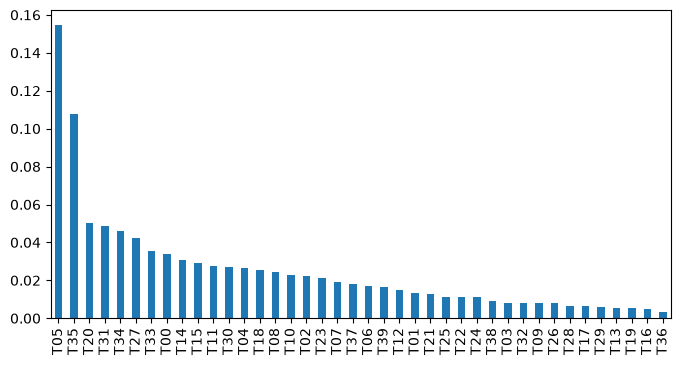

In [30]:
doc_topic .mean().sort_values(ascending=False).plot.bar(figsize=(8,4))
plt.show()

Look at distribution of topic weights for a sample of documents.

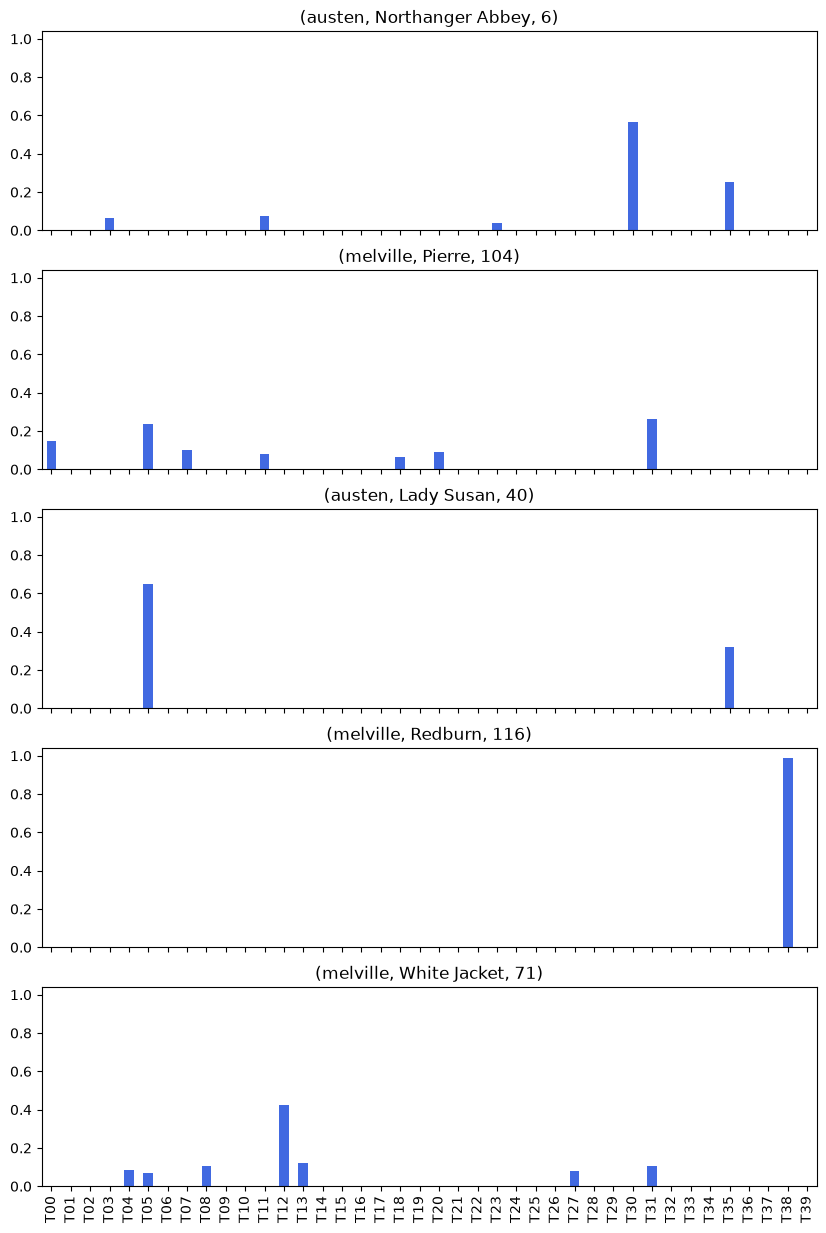

In [242]:
doc_topic.sample(5).T.plot.bar(figsize=(10,15), subplots=True, legend=False, color='royalblue', sharex=True, sharey=True)
plt.show()

### Aggregate topic weights by book

A $1{,}173$-leaf tree would be unreadable. In addition, per-chapter rows are also noisy: any single chapter can wander off-topic. 

A clearer object is one row **per book**, obtained by **averaging** the topic proportions across all of that book's chapters.

That gives us a compact **$19 \times 40$** matrix &mdash; $19$ books down the side, $40$ topics across the top &mdash; which is exactly the shape a dendrogram reads well.

In [244]:
book_topics = doc_topic .groupby(['author','title']).mean()
book_topics.index = [book[0][:3].upper() + ": " + book[1] for book in book_topics.index.values]
book_topics.index.name = 'book_label'
display(book_topics.shape)
book_topics.head()

(19, 40)

,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,...,T30,T31,T32,T33,T34,T35,T36,T37,T38,T39
book_label,,,,,,,,,,,,,,,,,,,,,
AUS: Emma,0.004450,0.000074,0.000074,0.000074,0.004008,0.461424,0.000074,0.000074,0.000617,0.000074,...,0.087484,0.000074,0.000193,0.002552,0.000133,0.369785,0.000074,0.000074,0.000074,0.000074
AUS: Lady Susan,0.007079,0.000584,0.001047,0.000584,0.002633,0.721677,0.001648,0.000584,0.001012,0.000584,...,0.020548,0.003630,0.000584,0.000584,0.000584,0.173152,0.000584,0.000584,0.000584,0.000584
AUS: Love And Friendship,0.041351,0.000600,0.000600,0.008498,0.000600,0.524438,0.000600,0.000600,0.006015,0.000600,...,0.094704,0.005834,0.001649,0.006597,0.000600,0.230213,0.000600,0.000600,0.000600,0.000600
AUS: Mansfield Park,0.010041,0.000060,0.000060,0.000814,0.000639,0.502889,0.000428,0.000870,0.001117,0.000060,...,0.067897,0.000060,0.001371,0.002212,0.002080,0.263304,0.000298,0.001274,0.001093,0.000854
AUS: Northanger Abbey,0.003664,0.001204,0.003225,0.002228,0.001750,0.390999,0.000203,0.000081,0.001778,0.000081,...,0.203989,0.001931,0.000081,0.003664,0.000081,0.229479,0.000253,0.000081,0.000081,0.000375


### Get distances between every pair of books

`scipy.spatial.distance.pdist` computes the distance between every pair of rows and returns them as a flat *condensed* vector (the upper triangle of the distance matrix). For $19$ books that is $\binom{19}{2} = 171$ pairwise distances.

In [70]:
from scipy.spatial.distance import pdist, squareform

dists = pdist(book_topics.values, metric='euclidean')

print("condensed distance vector length:", dists.shape[0])
print("that is C(19, 2) =", 19 * 18 // 2)

condensed distance vector length: 171
that is C(19, 2) = 171


### Run the merge loop to get linakage table

`scipy.cluster.hierarchy.linkage` runs the whole agglomerative loop for us and returns the merge history $Z$ &mdash; one row per merge, recording the two clusters joined and the height at which they joined. We use **ward** linkage.

In [245]:
from scipy.cluster.hierarchy import linkage

Z = linkage(dists, method='ward')

print("linkage matrix shape:", Z.shape, " (one row per merge; 18 merges for 19 books)")
Z[:5].round(4)

linkage matrix shape: (18, 4)  (one row per merge; 18 merges for 19 books)


array([[ 6.    ,  7.    ,  0.0507,  2.    ],
       [ 0.    ,  5.    ,  0.0777,  2.    ],
       [19.    , 20.    ,  0.0999,  4.    ],
       [ 2.    ,  3.    ,  0.1094,  2.    ],
       [ 4.    , 22.    ,  0.2246,  3.    ]])

### Draw the tree

`scipy.cluster.hierarchy.dendrogram` turns that merge history into the picture. 

We label each leaf with its **author and title** so we can read the tree.

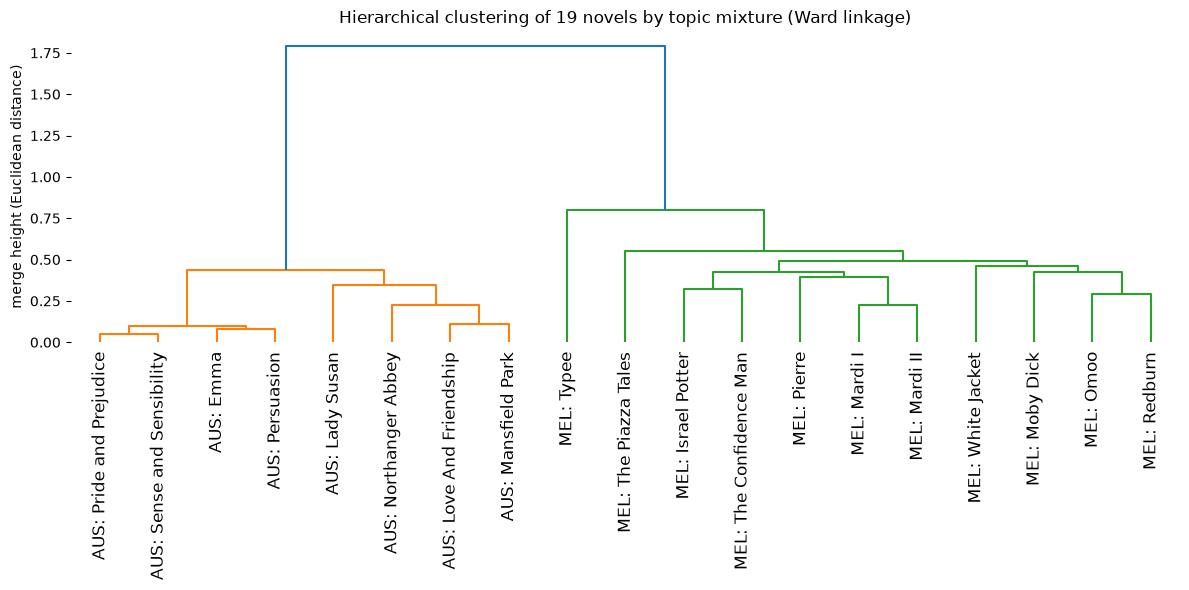

In [246]:
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z,
    labels=book_topics.index,
    leaf_rotation=90,
    ax=ax
)
ax.set_title("Hierarchical clustering of 19 novels by topic mixture (Ward linkage)")
ax.set_ylabel("merge height (Euclidean distance)")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Look at the top of the tree. There is one tall join that splits the whole set into **two branches**, and every join *below* it is much shorter.

Read the leaf labels under each branch: one side gathers *Emma*, *Persuasion*, *Pride and Prejudice*, *Mansfield Park* &mdash; the Austen novels. The other gathers *Moby-Dick*, *Typee*, *Omoo*, *White-Jacket* &mdash; the Melville novels.

The tree never saw an author. It only ever compared topic mixtures. And yet the deepest division it found is precisely the division between the two authors. That is the whole point of the lesson made visible in one figure.

### Rotate the tree

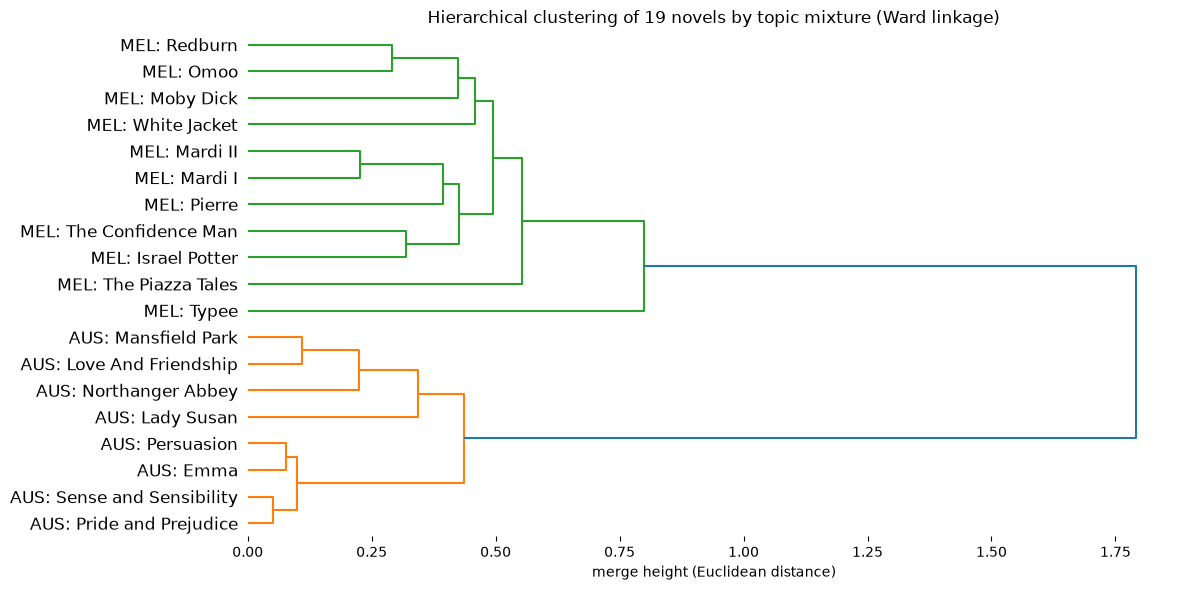

In [247]:
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z,
    labels=book_topics.index,
    leaf_rotation=0,
    ax=ax,
    orientation='right'
)
ax.set_title("Hierarchical clustering of 19 novels by topic mixture (Ward linkage)")
ax.set_xlabel("merge height (Euclidean distance)")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Cut the tree into flat clusters

Seeing the split is one thing; *measuring* it is another. 

To turn the tree into a definite grouping we **cut** it with a horizontal line.

`fcluster` does the cutting. Asking for `t=2` with `criterion='maxclust'` says: "cut wherever you must to leave exactly two clusters." That is the cut just below the tallest join.

In [248]:
from scipy.cluster.hierarchy import fcluster

book_clusters = pd.DataFrame({'cluster':fcluster(Z, t=2, criterion='maxclust')}, index=book_topics.index)
book_clusters

,cluster
book_label,
AUS: Emma,1
AUS: Lady Susan,1
AUS: Love And Friendship,1
AUS: Mansfield Park,1
AUS: Northanger Abbey,1
AUS: Persuasion,1
AUS: Pride and Prejudice,1
AUS: Sense and Sensibility,1
MEL: Israel Potter,2


We see that there are two labels, `1` and `2`, one per book. 

These are the model's guess at the two populations &mdash; still with no knowledge of authorship.

Since we know the authors, we can measure the performance of the cut using a **confusion matrix**.

We can create on with  **cross-tabulation** of the clusters against the true authors.

In [39]:
book_clusters.value_counts(['author','cluster']).unstack(fill_value=0)

cluster,1,2
author,,
austen,8,0
melville,0,11


The table is perfectly **block-diagonal**: one cluster contains all $8$ Austen novels and no Melville; the other contains all $11$ Melville novels and no Austen. Every off-diagonal cell is zero.

So, the unsupervised clustering recovered the author split with **$100\%$ accuracy** &mdash; a clean $8$-vs-$11$ partition that matches the ground truth exactly. Working from topic proportions alone, hierarchical clustering rediscovered the two authors.

## Create a function

To save time when visualizing a dendrogram, we can define a function that creates one with some parameters exposed. 

You can take this and save it to your own module and use it whenever you need it.

In [229]:
def treeplot(X, metric='euclidean', method='ward', dist_axis_len=6, orientation='right', data_desc="data"):
    
    Z = linkage(pdist(X.values, metric=metric), method=method)

    leaf_axis_len = X.shape[0] / 3
    dist_axis_label = f"merge height ({metric.title()} distance)"

    if orientation in ['top','bottom']:
        rotation = 90
        fig_height = leaf_axis_len
        fig_width = dist_axis_len
        y_label = dist_axis_label
        x_label = None
        grid_axis = "y"
        
    elif orientation in ['left','right']:
        rotation = 0
        fig_height = dist_axis_len
        fig_width = leaf_axis_len
        y_label = None
        x_label = dist_axis_label
        grid_axis = "x"

    else:
        raise ValueError("Invalid orientation parameter")

    fig, ax = plt.subplots(figsize=(fig_height, fig_width))
    dendrogram(
        Z,
        labels=X.index,
        orientation=orientation,
        leaf_rotation=rotation,
        leaf_font_size=10,
        ax=ax
    )
    ax.set_title(f"Hierarchical clustering of {data_desc} ({method.title()} linkage)")
    ax.set_ylabel(y_label)
    ax.set_xlabel(x_label)
    sns.despine(left=True, bottom=True)
    plt.grid(axis=grid_axis)
    plt.tight_layout()

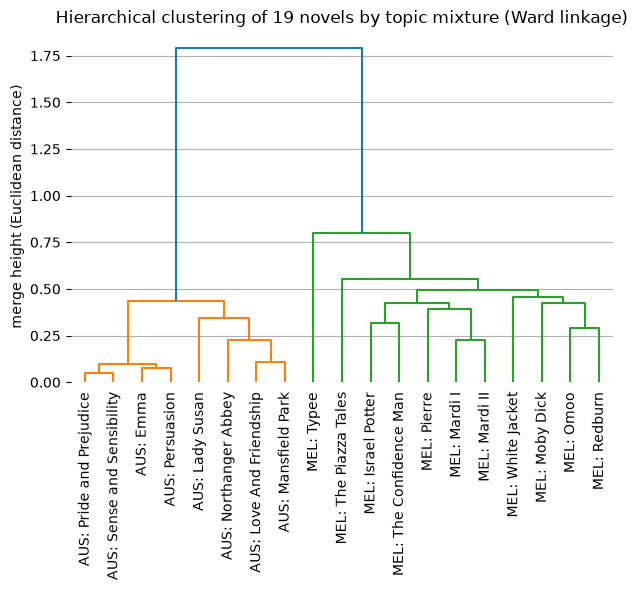

In [230]:
treeplot(book_topics, orientation='top', data_desc="19 novels by topic mixture")

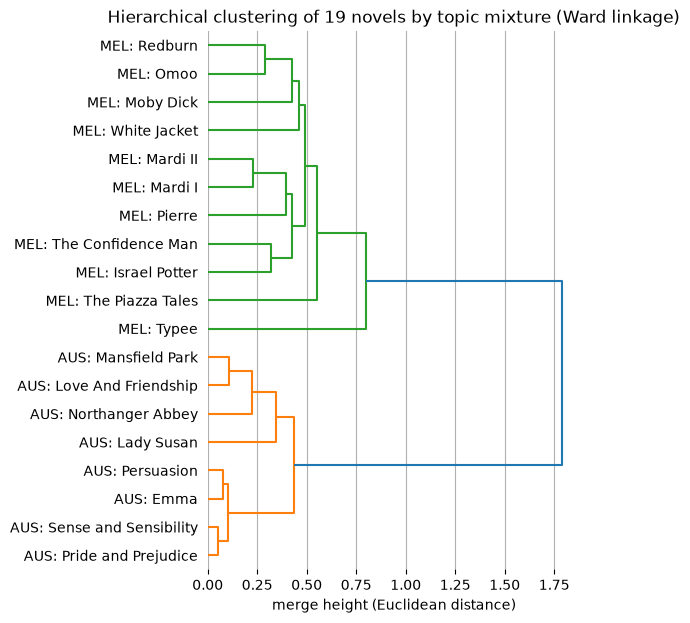

In [249]:
treeplot(book_topics, orientation='right', data_desc="19 novels by topic mixture")

## Use Seaborn's clustermap

A dendrogram sorts the leaves so that similar items end up next to each other. Seaborn's `clustermap` exploits that: it clusters the **rows** (and, if you like, the columns), reorders them, draws the heatmap in the new order, and pins the dendrograms to the edges.

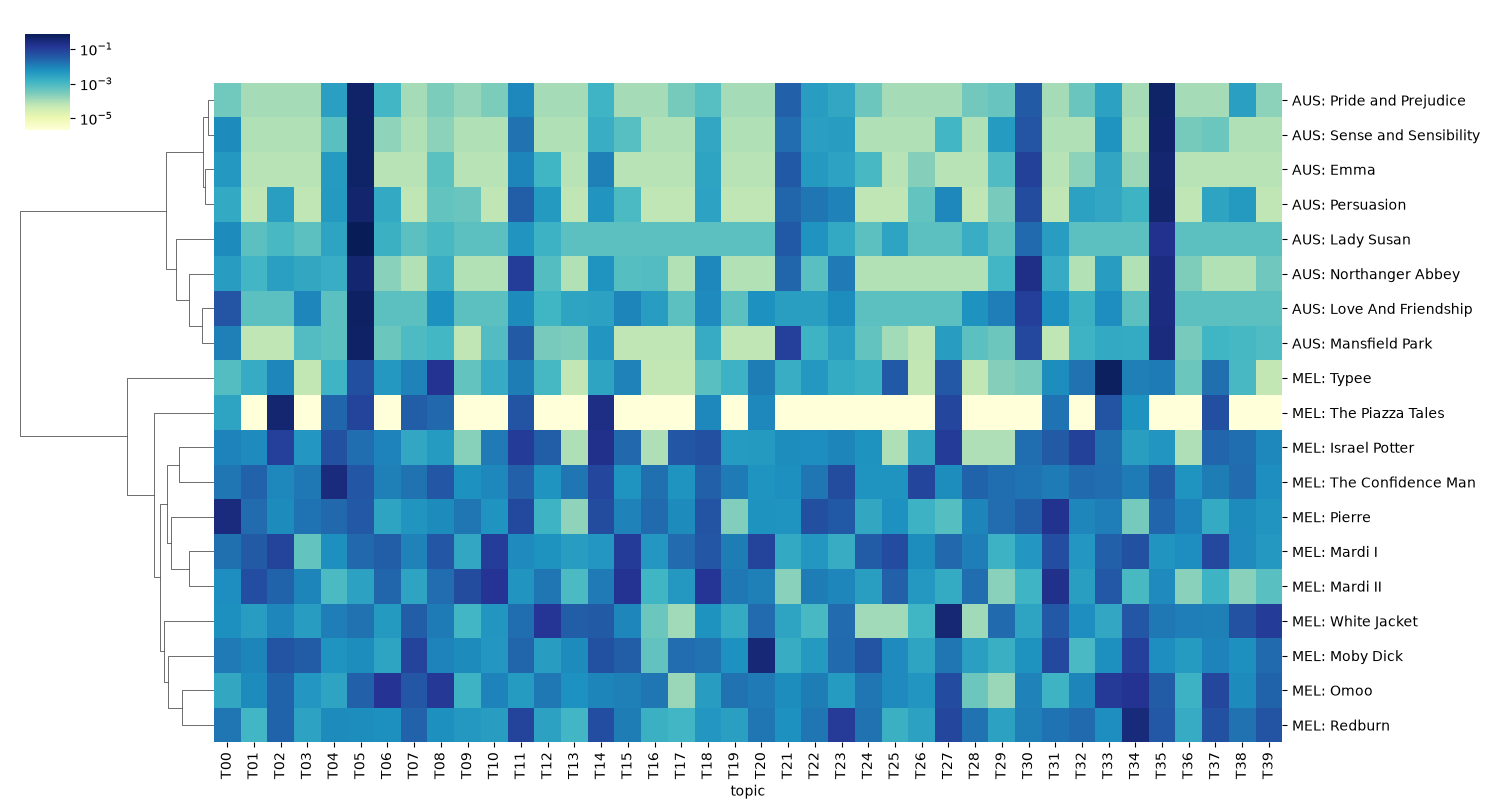

In [231]:
from matplotlib.colors import LogNorm

g = sns.clustermap(
    book_topics,
    method='ward',
    metric='euclidean',
    cmap='YlGnBu',
    norm=LogNorm(),
    figsize=(15, 8),
    col_cluster=None,
    dendrogram_ratio=(0.16, 0.10),
    cbar_pos=(0.02, 0.83, 0.03, 0.12),
)
g.ax_heatmap.set_xlabel("topic")
g.ax_heatmap.set_ylabel("")
plt.show()

A few `clustermap` parameters are worth knowing:

- **`method` / `metric`** choose the linkage and distance, exactly as in our from-scratch `linkage(pdist(...))`. We pass `ward` / `euclidean` to match.
- **Orientation.** The row dendrogram hangs on the left, the column dendrogram on top. You can suppress either with `row_cluster=False` or `col_cluster=False`.
- **`color_threshold`** (a `dendrogram` argument) sets the height below which branches share a color &mdash; handy for making the two clades pop.
- **`truncate_mode='lastp'`** collapses the bottom of a large tree into summary nodes, so you can cluster thousands of leaves and still show a legible top.

## How the linkage method changes the shape

The distances never change; the **linkage rule** does. Here are all four &mdash; single, complete, average, ward &mdash; on the same $19$-book matrix, as $2 \times 2$ small multiples.

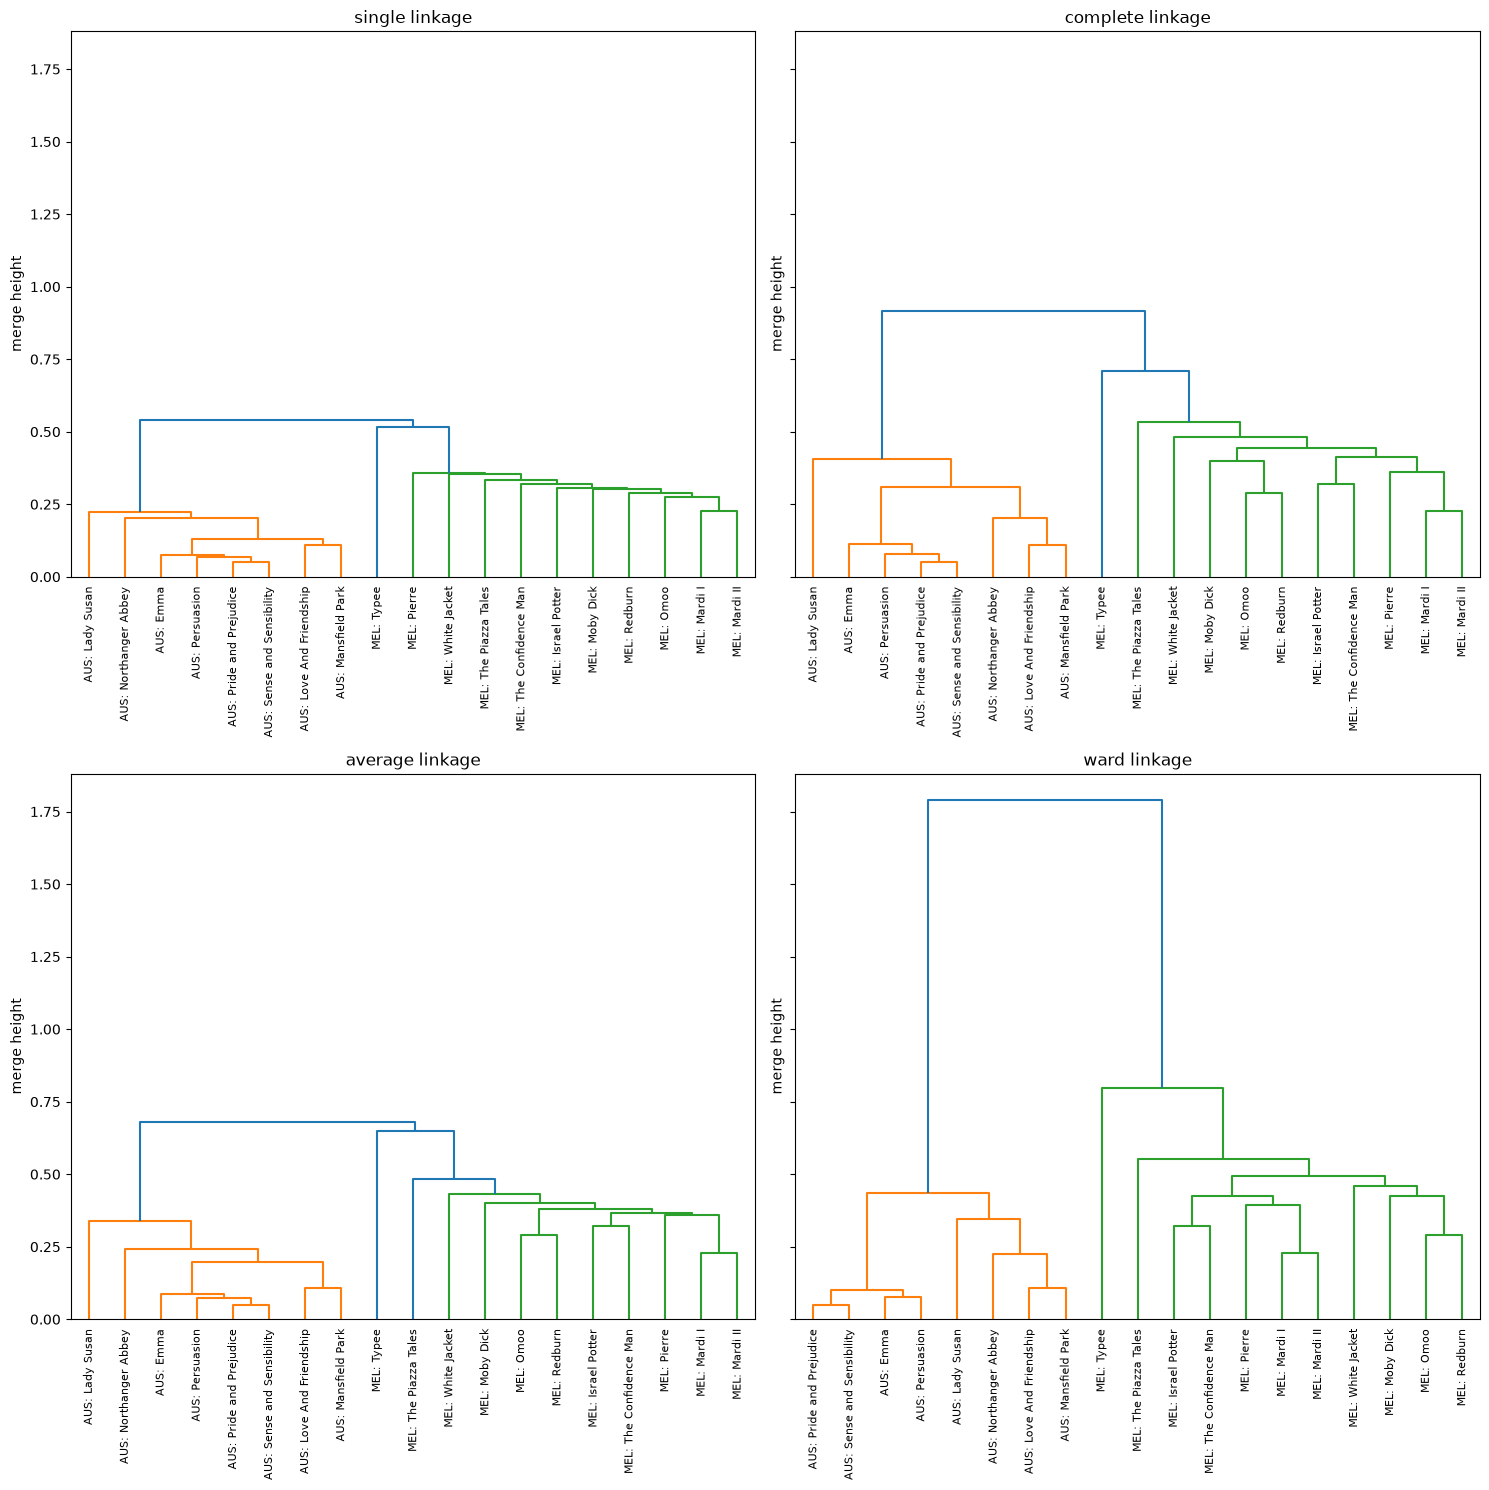

In [232]:
methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 15), sharey=True)

for method, ax in zip(methods, axes.ravel()):
    Zm = linkage(dists, method=method)
    dendrogram(Zm, labels=book_topics.index, leaf_rotation=90,
               leaf_font_size=8, ax=ax)
    ax.set_title(f"{method} linkage")
    ax.set_ylabel("merge height")

plt.tight_layout()
plt.show()

The trees really do differ:

- **Single linkage** shows its trademark *chaining*: books get tacked on one at a time, so there is no clean tall split at the top.
- **Complete** and **average** are tidier, raising two reasonably balanced groups.
- **Ward** gives the crispest picture &mdash; one dominant join at the top with the two author-clades hanging beneath it, and comfortable vertical separation between them.

## Does the split survive at the chapter level?

Averaging to $19$ books smooths away a lot of noise. A tougher test: cluster **individual chapters**, where a single chapter can drift off its author's usual topics.

We take a small *balanced* sample &mdash; $15$ Austen chapters and $15$ Melville chapters &mdash; cluster them, and color each leaf by its true author to see whether they still group.

T00       T01       T02       T03  \
       title               chapter                                           
austen Pride and Prejudice 49       0.000083  0.000083  0.000083  0.000083   
       Persuasion          13       0.000070  0.000070  0.000070  0.000070   
       Pride and Prejudice 51       0.000085  0.000085  0.000085  0.000085   
       Lady Susan          33       0.002273  0.002273  0.002273  0.002273   
       Emma                30       0.000088  0.000088  0.000088  0.000088   

                                         T04       T05       T06       T07  \
       title               chapter                                           
austen Pride and Prejudice 49       0.000083  0.507757  0.000083  0.000083   
       Persuasion          13       0.016803  0.478670  0.000070  0.000070   
       Pride and Prejudice 51       0.010754  0.323924  0.000085  0.000085   
       Lady Susan          33       0.002273  0.283367  0.002273  0.002273   
       Emma                30       0.000088  0.850861  0.000088  0.000088   

                                         T08       T09  ...       T30  \
       title               chapter                      ...             
austen Pride and Prejudice 49       0.000083  0.000083  ...  0.080251   
       Persuasion          13       0.000070  0.000070  ...  0.000070   
       Pride and Prejudice 51       0.000085  0.000085  ...  0.117492   
       Lady Susan          33       0.002273  0.002273  ...  0.002273   
       Emma                30       0.000088  0.000088  ...  0.145783   

                                         T31       T32       T33       T34  \
       title               chapter                                           
austen Pride and Prejudice 49       0.000083  0.000083  0.000083  0.000083   
       Persuasion          13       0.000070  0.000070  0.000070  0.000070   
       Pride and Prejudice 51       0.000085  0.000085  0.000085  0.000085   
       Lady Susan          33       0.002273  0.002273  0.002273  0.002273   
       Emma                30       0.000088  0.000088  0.000088  0.000088   

                                         T35       T36       T37       T38  \
       title               chapter                                           
austen Pride and Prejudice 49       0.387609  0.000083  0.000083  0.000083   
       Persuasion          13       0.396731  0.000070  0.000070  0.000070   
       Pride and Prejudice 51       0.530392  0.000085  0.000085  0.000085   
       Lady Susan          33       0.002273  0.002273  0.002273  0.002273   
       Emma                30       0.000088  0.000088  0.000088  0.000088   

                                         T39  
       title               chapter            
austen Pride and Prejudice 49       0.000083  
       Persuasion          13       0.000070  
       Pride and Prejudice 51       0.000085  
       Lady Susan          33       0.002273  
       Emma                30       0.000088  

[5 rows x 40 columns]

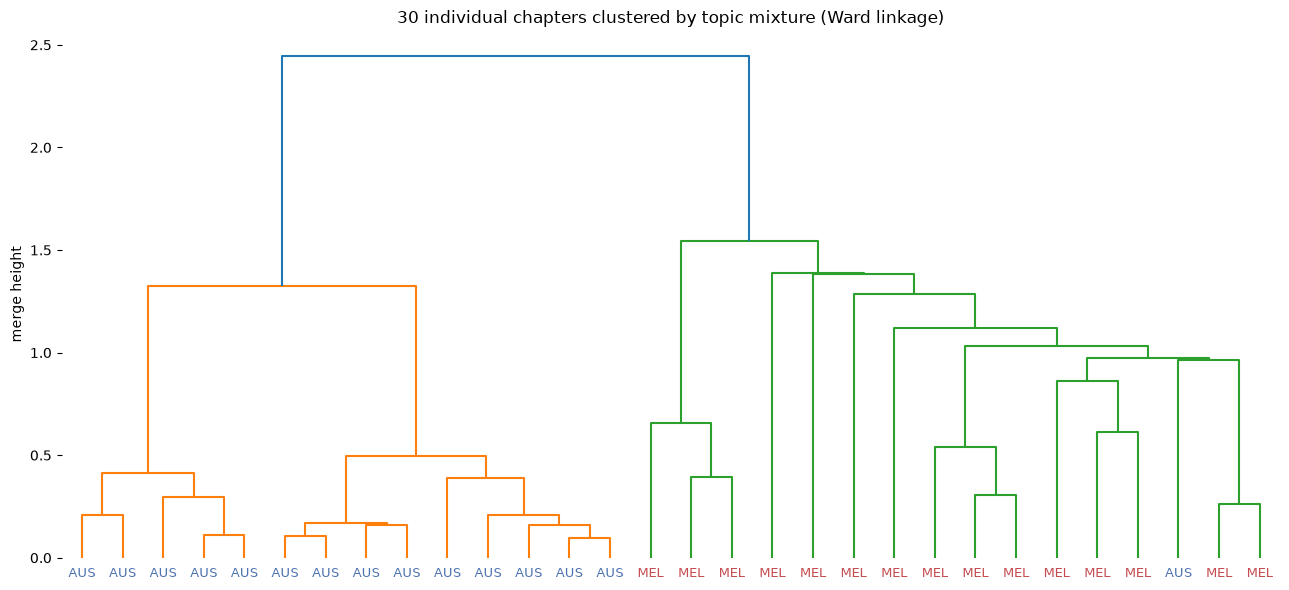

In [241]:
# Get unique list of authors
authors = doc_topic.reset_index().author.unique()

# Get a small, balanced sample 
sample = pd.concat([doc_topic.loc[auth].sample(15) for auth in authors], keys=authors)
display(sample.head())

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
dd = dendrogram(
    linkage(pdist(sample.values, metric='euclidean'), method='ward'), 
    labels=[idx[0][:3].upper() for idx in sample.index], 
    leaf_rotation=0,
    leaf_font_size=9, 
    ax=ax)
for lbl in ax.get_xticklabels():
    lbl.set_color('#4C72B0' if lbl.get_text() == 'AUS' else '#C44E52')
ax.set_title("30 individual chapters clustered by topic mixture (Ward linkage)")
ax.set_ylabel("merge height")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Even at the chapter level the two colors mostly stay on opposite sides of the tree. Cutting at `t=2` puts it in numbers.